## K-Means + tSNE

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib

import os
import numpy as np

from sklearn.cluster import KMeans

from src.colors import colors_new_legend
from src.connection import local_client as client

In [2]:
variables_path = "data/variables"
figures_path = "data/figures"
berenslab_data_path = "data/embeddings"

In [3]:
pubmed_ids = np.load(os.path.join(berenslab_data_path, "pubmed_ids.npy"))
article_dates = np.load(os.path.join(berenslab_data_path, "article_dates.npy"))
tsne = np.load(os.path.join(variables_path, "tsne_reparsed.npy"))

### Find the optimal number of clusters

In [4]:
def find_optimal_k(num_clusters):
    wcss = []
    for n in num_clusters:
        kmeans = KMeans(
            n_clusters=n,
            init="k-means++",
            n_init="auto",
            max_iter=300,
            random_state=42,
            ).fit(tsne)
        wcss.append(kmeans.inertia_)

    plt.plot(num_clusters, wcss)
    plt.xlabel("number of clusters")
    plt.ylabel("wcss")
    plt.show()

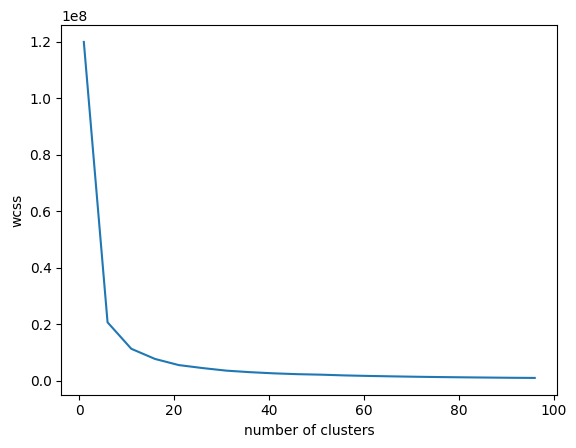

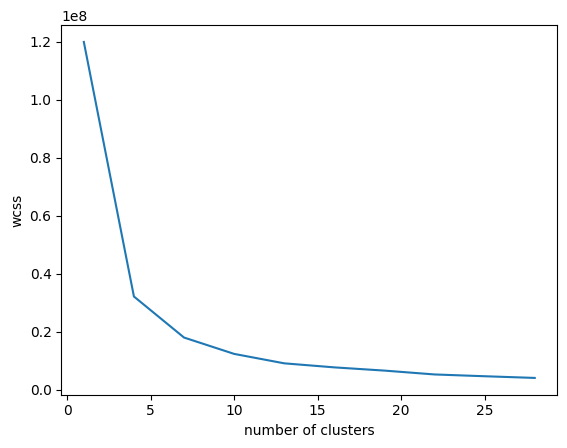

In [5]:
num_clusters = [i for i in range(1,101,5)]
find_optimal_k(num_clusters)
num_clusters = [i for i in range(1,31,3)]
find_optimal_k(num_clusters)

#### the optimal number is 7. The number seems too small, so still use 38 as the number of clusters.

## KMeans with n_clusters=38

In [6]:
kmeans = KMeans(
            n_clusters=38,
            init="k-means++",
            n_init="auto",
            max_iter=300,
            random_state=42,
            ).fit(tsne)

labels = kmeans.labels_

colors = [colors_new_legend[i] for i in labels]

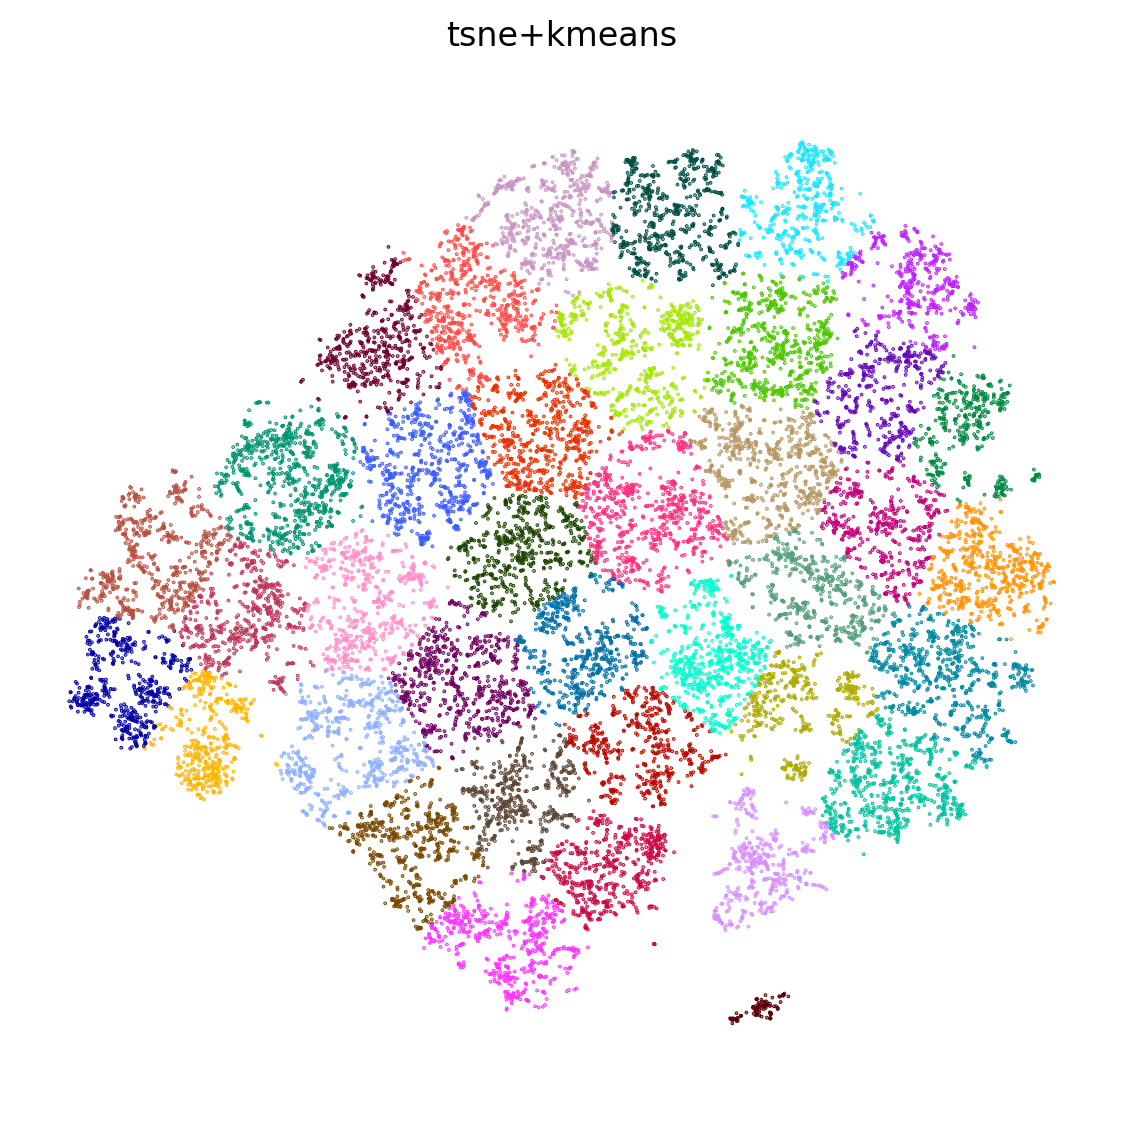

In [7]:
%matplotlib inline

# tsne = tsne
fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=200, layout="constrained")

ax.scatter(
    tsne[:, 0],
    tsne[:, 1],
    s=0.5,
    c=colors,
    marker=".",
)
ax.axis("equal")
ax.grid()
ax.axis("off")
ax.set_title("tsne+kmeans")
plt.show()

fig.savefig('data/results/tsne-kmeans.png')

# Export data to opensearch

In [8]:
label_index = "frameintell_insights"

# Read the mapping.json file
with open("mappings_frameintell_insights.json", "r") as mapping_file:
    mapping_json = mapping_file.read()

try:
    response = client.indices.create(label_index,body=mapping_json)
    print("Creating index:")
    print(response)
except Exception as e:
    print(e)

Creating index:
{'acknowledged': True, 'shards_acknowledged': True, 'index': 'frameintell_insights'}


In [9]:
reference_text = 'abstract'
dim_reduction_method = 'tsne'
clustering_method = 'kmeans'

docs = []
for i in range(len(tsne)):
    item_index = {"index": {"_index": label_index, "_id": f'{pubmed_ids[i]}:{reference_text}'}}
    item_data = {
        "origin_index": "frameintell_pubmed",
        "articleDate": article_dates[i],
        "reference_text":reference_text,
        "insights":[{
            'dim_reduction_method':dim_reduction_method,
            'reduced_dimension':tsne[i],
            'clustering_information':[{
                'clustering_method':clustering_method,
                'label': labels[i]
            }]
        }]
    }
    docs.append(item_index)
    docs.append(item_data)

resp = client.bulk(body=docs, index=label_index)

In [10]:
# 关闭连接
client.close()